# Ejercicio 2

In [1]:
from sympy import symbols, diff

j, k= symbols('j k', real=True)

f = k**2 - 2*j*k + 2*j**2 + 18*j - 20*k + 201
display(f)

df_dj = diff(f,j)
display(df_dj)

df_dk = diff(f,k)
display(df_dk)

e = 0.000001 
n = 0.05
(pj, pk) = (1, 1)
pz = f.evalf(subs = {j:pj, k:pk})
while True:
    rj = pj-n*df_dj.evalf(subs = {j:pj,k:pk})
    rk = pk-n*df_dk.evalf(subs = {j:pj,k:pk})
    rz = f.evalf(subs = {j:rj, k:rk})
    if(abs(rz - pz) < e):
        break
    pj = rj
    pk = rk
    pz = rz

print("Minimo en (%f,%f) vale %f" % (rj, rk, rz) )

2*j**2 - 2*j*k + 18*j + k**2 - 20*k + 201

4*j - 2*k + 18

-2*j + 2*k - 20

Minimo en (0.997044,10.995217) vale 100.000012


# Ejercicio 3

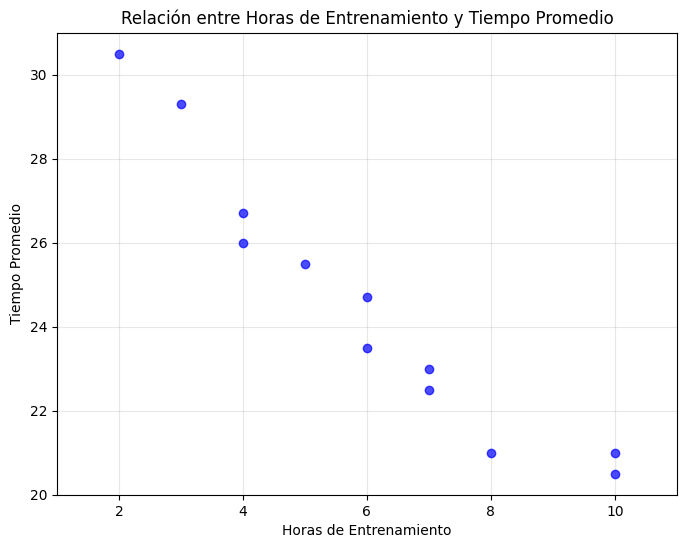

Coeficiente de correlación (Pearson): -0.960


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter

horas_entrenamiento = [2, 3, 4, 4, 5, 6, 6, 7, 7, 8, 10, 10]

tiempo_promedio = [30.5, 29.3, 26.7, 26, 25.5, 24.7, 23.5, 23, 22.5, 21, 21, 20.5]

X = np.array(horas_entrenamiento)
Y = np.array(tiempo_promedio)

# Gráfica de dispersión
plt.figure(figsize=(8, 6))
plt.plot(X, Y, 'o', color='blue', alpha=0.7, markersize=6)
plt.title('Relación entre Horas de Entrenamiento y Tiempo Promedio')
plt.xlabel('Horas de Entrenamiento')
plt.ylabel('Tiempo Promedio')
plt.grid(True, alpha=0.3)
plt.xlim(1, 11)
plt.ylim(20, 31)
plt.show()

# Cálculo del coeficiente de correlación
correlacion = np.corrcoef(X, Y)[0, 1]
print(f"Coeficiente de correlación (Pearson): {correlacion:.3f}")

In [3]:
import sys
import os

# Ruta absoluta a la carpeta "Fuentes"
ruta_fuentes = os.path.abspath(os.path.join(os.getcwd(), "..", "Fuentes"))
sys.path.append(ruta_fuentes)

from ClassNeuronaLineal import NeuronaLineal

x_train = X.reshape(-1,1)    # selecciona entradas y formatea a Nx1
y_train = Y.reshape(-1,1)    # selecciona salidas y formatea a Nx1

# entrena neurona lineal y grafica
modelo = NeuronaLineal(alpha=0.01, n_iter=500, cotaE=0.1, draw=0, title=['Horas', 'Tiempo'])
modelo = modelo.fit(x_train, y_train)
print('w =', modelo.w_[0])
print('b =', modelo.b_[0])

dato = 9 # horas de estudio dedicadas
print('Quien dedicó %d horas de entrenamiento tardará %d como tiempo promedio' % (dato, modelo.predict([dato])[0]))   # prediccio

w = -0.9519469280524693
b = 30.014279531874436
Quien dedicó 9 horas de entrenamiento tardará 21 como tiempo promedio


In [4]:
learning = 0.0005
epochs = 5000
# b0 es la ordenada al origen y b1 la pendiente de la recta de regresion lineal simple
b0, b1 = 0.0, 0.0

rng = np.random.default_rng(42)

for epoch in range(epochs):
    # ACÁ SE DA LO DE LOS MINILOTES, TOMAMOS UNA PERMUTACION RANDOM DE LAS VARAIABLES PARA CALCULAR ERROR
    indicies = rng.permutation(len(X))
    for i in indicies:
        xi = X[i]
        yi = Y[i]
        # Predicción de una variable actual
        y_pred = b0 + b1 * xi
        error = y_pred - yi
        # Actualizacion de ordenada al origen y pendiente
        b0 -= learning * error
        b1 -= learning * error * xi

print ("El b0 es", b0, "y el b1 es", b1)

# Punto de e)
X = 9
predict = b0 + b1 * X
print("Predicción para 9 horas de entrenamiento sin estandarizar:", predict)

El b0 es 31.324525786512535 y el b1 es -1.1442871804743586
Predicción para 9 horas de entrenamiento sin estandarizar: 21.025941162243306


# Ejercicio 4

In [5]:
import pandas as pd

ds_path = "../Datos/CCPP.csv"

try:
    df = pd.read_csv(ds_path)
    pd.set_option('display.float_format', '{:.4f}'.format)
    print(f"✅ Dataset cargado exitosamente!")
    print(f"\n🔍 Primeras 5 filas:")
    display(df.head(5))
except Exception as e:
    print(f"❌ Error al cargar: {e}")

✅ Dataset cargado exitosamente!

🔍 Primeras 5 filas:


,AT,V,AP,RH,PE
0,14.9600,41.7600,1024.0700,73.1700,463.2600
1,25.1800,62.9600,1020.0400,59.0800,444.3700
2,5.1100,39.4000,1012.1600,92.1400,488.5600
3,20.8600,57.3200,1010.2400,76.6400,446.4800
4,10.8200,37.5000,1009.2300,96.6200,473.9000


In [6]:
X = df[["AT"]].values  
T = df["PE"].values

parametros = [
    ("a", -2.00, 500),
    ("b", -2.21, 498),
    ("c", -2.30, 497),
    ("d", -2.22, 496.5),
    ("e", -2.16, 496.91),
]

resultados = []
for nombre, W, b in parametros:
    modelo = NeuronaLineal(alpha=0.01, n_iter=500, cotaE=0.1)
    modelo.w_ = np.array([W], dtype=float)
    modelo.b_ = float(b)
    Y = modelo.predict(X)
    mse = np.mean((T - Y)**2)
    resultados.append((nombre, W, b, mse))
    print(f"{nombre}) W={W}, b={b} -> MSE={mse:.4f}")

resultados.sort(key=lambda t: t[3])
print("\nLos dos combinadores con menor MSE son:")
for r in resultados[:2]:
    print(f"{r[0]}) W={r[1]}, b={r[2]} -> MSE={r[3]:.4f}")

a) W=-2.0, b=500 -> MSE=71.1626
b) W=-2.21, b=498 -> MSE=29.5571
c) W=-2.3, b=497 -> MSE=36.9194
d) W=-2.22, b=496.5 -> MSE=31.7856
e) W=-2.16, b=496.91 -> MSE=29.4485

Los dos combinadores con menor MSE son:
e) W=-2.16, b=496.91 -> MSE=29.4485
b) W=-2.21, b=498 -> MSE=29.5571


# Ejercicio 5

In [7]:
ds_path = "../Datos/automobile-simple.csv"

try:
    df = pd.read_csv(ds_path)
    pd.set_option('display.float_format', '{:.4f}'.format)
    print(f"✅ Dataset cargado exitosamente!")
    print(f"\n🔍 Primeras 5 filas:")
    display(df.head(5))
except Exception as e:
    print(f"❌ Error al cargar: {e}")

✅ Dataset cargado exitosamente!

🔍 Primeras 5 filas:


,make,fuel-type,num-of-doors,body-style,curb-weight,engine-size,horsepower,city-mpg,highway-mpg,price,volume,eco-rating
0,alfa-romero,gas,two,convertible,2548,130,111.0000,21,27,13495.0000,528019.9040,33.2975
1,alfa-romero,gas,two,convertible,2548,130,111.0000,21,27,16500.0000,528019.9040,33.2975
2,alfa-romero,gas,two,hatchback,2823,152,154.0000,19,26,16500.0000,587592.6400,30.8983
3,audi,gas,four,sedan,2337,109,102.0000,24,30,13950.0000,634816.9560,42.6978
4,audi,gas,four,sedan,2824,136,115.0000,18,22,17450.0000,636734.8320,27.9975


In [8]:
print('Antes:\n',df["price"].isnull().sum(), '\n')

df['price'].fillna(df['price'].mean(), inplace=True)

print('Despues:\n',df["price"].isnull().sum(), '\n')

Antes:
 4 

Despues:
 0 



C:\Users\gonza\AppData\Local\Temp\ipykernel_6832\251459492.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['price'].fillna(df['price'].mean(), inplace=True)


In [9]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
def train_and_get_error(X, y, alpha=0.001, n_iter=2000):
    neurona = NeuronaLineal(alpha=alpha, n_iter=n_iter, draw=0)
    neurona.fit(X, y)
    y_pred = neurona.predict(X)
    mse = np.mean((y_pred - y) ** 2)
    return neurona, mse

# Sin normalizar
X = df[['engine-size']].to_numpy(dtype=np.float64)
y = df['price'].to_numpy(dtype=np.float64).reshape(-1, 1).ravel()
neurona, mse = train_and_get_error(X, y, alpha=1e-6, n_iter=2000)
print(f"Neurona entrenada: W={neurona.w_[0]}, b={neurona.b_} -> MSE={mse:.4f}")

scaler = StandardScaler()
X = scaler.fit_transform(df[['engine-size']].to_numpy(dtype=float))
y = scaler.fit_transform(df['price'].to_numpy(dtype=float).reshape(-1, 1)).ravel()
neurona, mse = train_and_get_error(X, y)
print(f"Neurona entrenada: W={neurona.w_[0]}, b={neurona.b_} -> MSE={mse:.4f}")

scaler = MinMaxScaler()
X = scaler.fit_transform(df[['engine-size']].to_numpy(dtype=float))
y = scaler.fit_transform(df['price'].to_numpy(dtype=float).reshape(-1, 1)).ravel()
neurona, mse = train_and_get_error(X, y)
print(f"Neurona entrenada: W={neurona.w_[0]}, b={neurona.b_} -> MSE={mse:.4f}")

Neurona entrenada: W=106.70416731013299, b=-268.56862003027084 -> MSE=21300274.4273
Neurona entrenada: W=0.858779544375015, b=-0.0044202231975070585 -> MSE=0.2574
Neurona entrenada: W=1.066155794545277, b=-0.06536686705137706 -> MSE=0.0098


# Ejercicio 6

In [25]:
X = np.array([
    (0, 0, 0),
    (0, 0, 1),
    (0, 1, 0),
    (0, 1, 1),
    (1, 0, 0),
    (1, 0, 1),
    (1, 1, 0),
    (1, 1, 1)
])

T = [ 0, 1, 2, 3, 4, 5, 6, 7]

modelo = NeuronaLineal(alpha=1e-6, n_iter=2000, cotaE=0.000001)

modelo.fit(X, T)
print('w =', modelo.w_)
print('b =', modelo.b_)

# imprime errores de cada iteracion:
print('Errores:')
for i, err in enumerate(modelo.errors_):
    print('%3d => %f' % (i, err))

    
Y = modelo.predict(X)
mse = np.mean((T - Y)**2)
print(Y)
print('mse:', mse)

w = [-0.37349147  0.05746891 -0.00334506]
b = 0.0533852089126718
Errores:
  0 => 159.991764
  1 => 159.987576
  2 => 159.983387
  3 => 159.979199
  4 => 159.975012
  5 => 159.970824
  6 => 159.966636
  7 => 159.962449
  8 => 159.958261
  9 => 159.954074
 10 => 159.949887
 11 => 159.945700
 12 => 159.941513
 13 => 159.937326
 14 => 159.933140
 15 => 159.928953
 16 => 159.924767
 17 => 159.920580
 18 => 159.916394
 19 => 159.912208
 20 => 159.908022
 21 => 159.903837
 22 => 159.899651
 23 => 159.895465
 24 => 159.891280
 25 => 159.887095
 26 => 159.882910
 27 => 159.878725
 28 => 159.874540
 29 => 159.870355
 30 => 159.866170
 31 => 159.861986
 32 => 159.857801
 33 => 159.853617
 34 => 159.849433
 35 => 159.845249
 36 => 159.841065
 37 => 159.836881
 38 => 159.832697
 39 => 159.828514
 40 => 159.824330
 41 => 159.820147
 42 => 159.815964
 43 => 159.811781
 44 => 159.807598
 45 => 159.803415
 46 => 159.799232
 47 => 159.795050
 48 => 159.790867
 49 => 159.786685
 50 => 159.782503
 51 => 1